# Spatial Machine Learning for EO-Derived Landscape Change Detection


### Objective

---

The objective of this experiment is to evaluate whether multi-temporal Earth Observation (EO) features—derived from Sentinel-1 SAR, Sentinel-2 optical imagery, and SRTM topographic elevation—can effectively learn and predict an EO-derived binary landscape-change pattern across **spatially separated geographical regions**.

The target variable `Y` represents an EO-derived rule-based change label established in Stage 1 (top 20% composite anomaly score). It is **not treated as independent ground truth**. `CEMS EMSR927` rapid mapping serves as external event context and is not the source of `Y`.

Primary modeling comprises an interpretable linear baseline (**Logistic Regression**) benchmarked against a nonlinear tree ensemble (**Random Forest**). Spatial block-based partitioning is enforced throughout to eliminate optimistic spatial autocorrelation leakage between training, validation, and test observations.


## Environment & Imports

---

Import required Python libraries for tabular manipulation, spatial analysis, pipeline construction, machine learning modeling, and diagnostic visualization. We interface with the project's companion module (`Module.spatial_ml`) and centralized configuration (`configs/ml_config.json`).


In [1]:
import sys, json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

# Resolve project root dynamically
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR
for p in [PROJECT_ROOT, PROJECT_ROOT / "configs"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Load centralized configuration directly from configs/ml_config.json
import Module.spatial_ml as sml
cfg = sml.load_ml_config()

# Configure visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Environment and modules successfully initialized.")


Environment and modules successfully initialized.


## Configuration & Global Hyperparameters

---

Global configuration is loaded from `configs/ml_config.json` via `Module.spatial_ml.load_ml_config()`. Centralizing these settings ensures absolute consistency across experimental runs.


In [2]:
# Display centralized configuration
print(f"""
Random State: {cfg['RANDOM_STATE']}\n
Default Spatial Block Size: {cfg['DEFAULT_BLOCK_SIZE']}° (~{cfg['DEFAULT_BLOCK_SIZE'] * 111:.1f} km)\n
Candidate Block Sizes: {cfg['CANDIDATE_BLOCK_SIZES']}\n
Split Ratios: {cfg['SPLIT_RATIOS']}\n
Logistic Regression Params: {cfg['LOGISTIC_REGRESSION']}\n
Random Forest Params: {cfg['RANDOM_FOREST']}\n""")

DATA_DIR = PROJECT_ROOT / "Data"
INPUT_FILE = PROJECT_ROOT / cfg["PATHS"]["INPUT_FILE"]
SPATIAL_SPLIT_FILE = PROJECT_ROOT / cfg["PATHS"]["SPATIAL_SPLIT_FILE"]
PREDICTION_FILE = PROJECT_ROOT / cfg["PATHS"]["PREDICTION_FILE"]
MODEL_FILE = PROJECT_ROOT / cfg["PATHS"]["MODEL_FILE"]
ABLATION_FILE = PROJECT_ROOT / cfg["PATHS"]["ABLATION_FILE"]

print(f"Input Data Path: {INPUT_FILE}")



Random State: 42

Default Spatial Block Size: 0.02° (~2.2 km)

Candidate Block Sizes: [0.01, 0.02, 0.03]

Split Ratios: {'DEV_SIZE': 0.8, 'TEST_SIZE': 0.2, 'TRAIN_SIZE': 0.75, 'VAL_SIZE': 0.25, 'N_FOLDS': 4}

Logistic Regression Params: {'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}

Random Forest Params: {'n_estimators': 300, 'min_samples_leaf': 2, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}

Input Data Path: s:\Nepal_Flood\Data\EO_feature_table_labelled.csv


## Dataset Loading

---

We load the labeled feature table generated in Stage 1 (`EO_feature_table_labelled.csv`). This table contains pixel-level geographic coordinates, Sentinel-1 SAR polarimetric indices, Sentinel-2 spectral indices, SRTM topographic DEM and slope, and the binary proxy target label `Y`.


In [3]:
assert INPUT_FILE.exists(), f"Input dataset not found at {INPUT_FILE}"

df_raw = pd.read_csv(INPUT_FILE)
print(f"Dataset successfully loaded. Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory footprint: {df_raw.memory_usage().sum() / (1024**2):.2f} MB")
df_raw.head()


Dataset successfully loaded. Shape: 123,154 rows x 20 columns
Memory footprint: 18.79 MB


,longitude,latitude,VV_pre,VH_pre,VV_post,VH_post,dVV,dVH,NDVI_pre,NDWI_pre,NDBI_pre,NDVI_post,NDWI_post,NDBI_post,dNDVI,dNDWI,dNDBI,DEM,slope,Y
0,84.961400,28.24977,-5.476773,-10.613767,-11.241003,-16.421955,-5.764230,-5.808188,0.277536,-0.238257,-0.187029,-0.023382,0.048325,-0.239668,-0.300918,0.286582,-0.052640,3180.3720,33.920853,0
1,84.961670,28.24977,-7.726924,-14.242751,-13.889768,-18.039024,-6.162843,-3.796273,0.284828,-0.233265,-0.197048,-0.025147,0.050335,-0.239580,-0.309975,0.283601,-0.042532,3163.3430,35.998850,0
2,84.961945,28.24977,-7.920870,-16.649810,-19.442646,-21.421860,-11.521776,-4.772049,0.318496,-0.242523,-0.203874,-0.035690,0.055236,-0.229617,-0.354186,0.297759,-0.025743,3146.1123,37.426870,1
3,84.962210,28.24977,-9.971469,-14.727584,-13.311932,-20.090908,-3.340463,-5.363324,0.309348,-0.250789,-0.187975,-0.034270,0.054471,-0.230624,-0.343618,0.305260,-0.042649,3133.9768,40.186646,0
4,84.962480,28.24977,-6.222614,-10.452959,-6.218465,-13.293015,0.004149,-2.840056,0.271031,-0.217728,-0.155744,-0.033520,0.055649,-0.230829,-0.304551,0.273377,-0.075085,3131.5923,44.612310,0


## Data Audit & Quality Control

---

Before any partitioning or model fitting, a thorough data quality audit is conducted to examine:

- Presence of missing or infinite values
- Exact duplicate records versus natural spatial co-occurrences
- Target variable distribution (`Y`)
- Coordinate sanity and geographic bounds
- Feature distribution ranges


In [4]:
# Missing Value Audit
missing_counts = df_raw.isna().sum()
missing_pct = (missing_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage (%)": missing_pct})
print("\n### Missing Values Audit")
print(missing_df[missing_df["Missing Count"] > 0] if (missing_counts > 0).any() else "Zero missing values detected across all columns.")

# Exact Duplicate Records Check
exact_duplicates = df_raw.duplicated().sum()
print(f"\nExact duplicate rows count: {exact_duplicates:,}")

# Target Variable (Y) Audit
print("\n### Target Variable (Y) Distribution ")
y_counts = df_raw["Y"].value_counts().rename("Count")
y_props = df_raw["Y"].value_counts(normalize=True).rename("Proportion (%)") * 100
target_summary = pd.concat([y_counts, y_props.round(2)], axis=1)
display(target_summary)

# Geographic Coordinate Audit
print("\n### Geographic Coordinate Extent ")
coord_stats = df_raw[["longitude", "latitude"]].describe().T[["min", "mean", "max"]]
display(coord_stats)

# Feature Distributions Summary
print("\n### Numerical Feature Distributions Summary ")
display(df_raw.describe().T[["min", "mean", "50%", "max", "std"]].round(3))



### Missing Values Audit
Zero missing values detected across all columns.

Exact duplicate rows count: 0

### Target Variable (Y) Distribution 


,Count,Proportion (%)
Y,,
0,98523,80.0
1,24631,20.0



### Geographic Coordinate Extent 


,min,mean,max
longitude,84.961400,84.981529,84.99994
latitude,28.000217,28.127814,28.24977



### Numerical Feature Distributions Summary 


,min,mean,50%,max,std
longitude,84.961,84.982,84.982,85.000,0.010
latitude,28.000,28.128,28.129,28.250,0.072
VV_pre,-20.013,-7.237,-7.282,6.653,2.398
VH_pre,-27.551,-13.685,-13.717,-0.627,2.321
VV_post,-32.174,-8.377,-8.752,16.970,6.097
VH_post,-39.271,-14.717,-15.128,8.509,5.639
dVV,-21.752,-1.140,-1.102,18.725,5.838
dVH,-26.349,-1.032,-0.984,17.267,5.516
NDVI_pre,-0.234,0.179,0.128,0.891,0.165
NDWI_pre,-0.818,-0.134,-0.090,0.263,0.151


## Feature Definition & Leakage Prevention

---

We formalize feature groups according to the satellite sensor modalities and topographic attributes.

> **Target Leakage Warning**:
> Predictive models must strictly exclude `Y`, `change_score`, or any other proxy anomaly scores that directly define or encode the target label.


In [5]:
S1_FEATURES = cfg["FEATURE_GROUPS"]["S1_FEATURES"]
S2_FEATURES = cfg["FEATURE_GROUPS"]["S2_FEATURES"]
TERRAIN_FEATURES = cfg["FEATURE_GROUPS"]["TERRAIN_FEATURES"]
ALL_PREDICTORS = S1_FEATURES + S2_FEATURES + TERRAIN_FEATURES

print(f"Sentinel-1 SAR Features ({len(S1_FEATURES)}): {S1_FEATURES}")
print(f"Sentinel-2 Optical Features ({len(S2_FEATURES)}): {S2_FEATURES}")
print(f"Terrain Features ({len(TERRAIN_FEATURES)}): {TERRAIN_FEATURES}")
print(f"Total Predictive Features: {len(ALL_PREDICTORS)}")

# Leakage Safeguard: Verify that target column or proxy scores are NOT in feature sets
forbidden_cols = {"Y", "change_score", "rule_based_score"}
leakage_detected = forbidden_cols.intersection(set(ALL_PREDICTORS))
assert len(leakage_detected) == 0, f"Target leakage detected in predictors: {leakage_detected}"
print("Leakage verification passed: No target or score columns present in predictor set.")


Sentinel-1 SAR Features (6): ['VV_pre', 'VH_pre', 'VV_post', 'VH_post', 'dVV', 'dVH']
Sentinel-2 Optical Features (9): ['NDVI_pre', 'NDWI_pre', 'NDBI_pre', 'NDVI_post', 'NDWI_post', 'NDBI_post', 'dNDVI', 'dNDWI', 'dNDBI']
Terrain Features (2): ['DEM', 'slope']
Total Predictive Features: 17
Leakage verification passed: No target or score columns present in predictor set.


## Spatial Block Construction & Sensitivity Analysis

---

In spatial Earth Observation datasets, neighboring pixels exhibit strong `spatial autocorrelation (Tobler's First Law of Geography)`. An ordinary random pixel-level split causes severe optimistic bias because pixels from the exact same landscape patch appear in both training and test sets.

To test true geographic generalization, we aggregate coordinates into discrete regular spatial grid cells:
$$\text{lon\_block} = \left\lfloor \frac{\text{longitude}}{\text{BLOCK\_SIZE}} \right\rfloor, \quad \text{lat\_block} = \left\lfloor \frac{\text{latitude}}{\text{BLOCK\_SIZE}} \right\rfloor$$
$$\text{spatial\_block} = \text{lon\_block}\_\text{lat\_block}$$

Before locking in the final partition, we evaluate candidate grid sizes (`0.01°`, `0.02°`, `0.03°`) to observe block counts and class balance stability.


In [6]:
# Evaluate candidate block sizes
sensitivity_df = sml.evaluate_block_size_sensitivity(
	df=df_raw,
	candidate_sizes=cfg["CANDIDATE_BLOCK_SIZES"],
	lon_col="longitude",
	lat_col="latitude",
	target_col="Y"
)
display(sensitivity_df)

# Construct final spatial blocks using selected configuration (BLOCK_SIZE = 0.02 deg)
BLOCK_SIZE = cfg["DEFAULT_BLOCK_SIZE"]
df_blocked = sml.construct_spatial_blocks(
    df=df_raw,
    block_size=BLOCK_SIZE,
    lon_col="longitude",
    lat_col="latitude"
)

num_blocks = df_blocked["spatial_block"].nunique()
print(f"\nConstructed {num_blocks} discrete spatial blocks with BLOCK_SIZE = {BLOCK_SIZE}° (~{BLOCK_SIZE*111:.1f} km)")
print(f"Pixels per block: Min = {df_blocked['spatial_block'].value_counts().min():,}, "
      f"Median = {df_blocked['spatial_block'].value_counts().median():,.0f}, "
      f"Max = {df_blocked['spatial_block'].value_counts().max():,}")

,block_size_deg,approx_km,num_blocks,min_pixels_per_block,median_pixels_per_block,max_pixels_per_block,mean_class1_ratio,std_class1_ratio
0,0.01,1.11,100,543,1337.5,1444,0.201435,0.175730
1,0.02,2.22,26,2578,5025.0,5387,0.208441,0.133808
2,0.03,3.33,18,2563,5248.5,11601,0.192751,0.118727



Constructed 26 discrete spatial blocks with BLOCK_SIZE = 0.02° (~2.2 km)
Pixels per block: Min = 2,578, Median = 5,025, Max = 5,387


## Spatial Data Partitioning

---

We execute a two-stage `GroupShuffleSplit` grouping strictly on `spatial_block`:

**Stage 1**: Partition full dataset into Development (80%) and Test (20%).  
 **Stage 2**: Partition Development into Training (75% of dev $\approx$ 60% of total) and Validation (25% of dev $\approx$ 20% of total).


In [7]:
train_df, val_df, test_df, full_df_split = sml.spatial_train_val_test_split(
    df=df_blocked,
    group_col="spatial_block",
    dev_size=cfg["SPLIT_RATIOS"]["DEV_SIZE"],
    test_size=cfg["SPLIT_RATIOS"]["TEST_SIZE"],
    train_size=cfg["SPLIT_RATIOS"]["TRAIN_SIZE"],
    val_size=cfg["SPLIT_RATIOS"]["VAL_SIZE"],
    random_state=cfg["RANDOM_STATE"]
)

print(f"Training observations:   {len(train_df):,} ({len(train_df)/len(full_df_split)*100:.1f}%)")
print(f"Validation observations: {len(val_df):,} ({len(val_df)/len(full_df_split)*100:.1f}%)")
print(f"Test observations:       {len(test_df):,} ({len(test_df)/len(full_df_split)*100:.1f}%)")


Training observations:   72,437 (58.8%)
Validation observations: 21,366 (17.3%)
Test observations:       29,351 (23.8%)


## Split Diagnostics & Leakage Verification

---

We programmatically verify that no spatial block appears in more than one partition.


In [8]:
# Run strict leakage assertions
leakage_report = sml.verify_split_leakage(train_df, val_df, test_df, group_col="spatial_block")
print("Spatial Leakage Verification:")
for k, v in leakage_report.items():
    print(f"  {k}: {v}")

# Build diagnostic summary table
summary_records = []
for name, subset in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    counts = subset["Y"].value_counts()
    summary_records.append({
        "Split": name,
        "Total Rows": len(subset),
        "Share (%)": round(len(subset) / len(full_df_split) * 100, 2),
        "Num Blocks": subset["spatial_block"].nunique(),
        "Y=0 (No Change)": counts.get(0, 0),
        "Y=1 (Change)": counts.get(1, 0),
        "Class 1 Ratio (%)": round(subset["Y"].mean() * 100, 2)
    })

split_summary_df = pd.DataFrame(summary_records)
display(split_summary_df)

Spatial Leakage Verification:
  train_blocks: 15
  val_blocks: 5
  test_blocks: 6
  train_val_overlap: 0
  train_test_overlap: 0
  val_test_overlap: 0
  leakage_status: PASSED (Zero spatial block leakage)


,Split,Total Rows,Share (%),Num Blocks,Y=0 (No Change),Y=1 (Change),Class 1 Ratio (%)
0,Train,72437,58.82,15,59753,12684,17.51
1,Validation,21366,17.35,5,15569,5797,27.13
2,Test,29351,23.83,6,23201,6150,20.95


## Spatial Split Dataset Export

---

We persist the spatial split table to `Data/EO_feature_table_spatial_split.csv` containing the assigned `split` label (`train`, `validation`, `test`) and block metadata for full auditability.


In [9]:
full_df_split.to_csv(SPATIAL_SPLIT_FILE, index=False)
print(f"Spatial split dataset saved to: {SPATIAL_SPLIT_FILE}")
print(f"File size: {SPATIAL_SPLIT_FILE.stat().st_size / (1024**2):.2f} MB")

Spatial split dataset saved to: s:\Nepal_Flood\Data\EO_feature_table_spatial_split.csv
File size: 27.73 MB


## Data Preparation & Preprocessing Pipeline

---

We isolate predictor arrays `X` and target vectors `y`.

> **Preprocessing Rule**:
> `StandardScaler` is fitted strictly on `X_train`. Validation and Test partitions are transformed using the parameters learned from training data only.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Isolate 80% Development set (Train + Val blocks) for Spatial GroupKFold Cross-Validation
dev_df = full_df_split[full_df_split["split"].isin(["train", "validation"])].copy()

X_train = train_df[ALL_PREDICTORS].values
y_train = train_df["Y"].values

X_val = val_df[ALL_PREDICTORS].values
y_val = val_df["Y"].values

X_test = test_df[ALL_PREDICTORS].values
y_test = test_df["Y"].values

print(f"Feature matrix shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Target shapes:         y_train={y_train.shape}, y_val={y_val.shape}, y_test={y_test.shape}")
print(f"Development set:       dev_df={dev_df.shape} ({dev_df['spatial_block'].nunique()} blocks for Spatial CV)")


Feature matrix shapes: X_train=(72437, 17), X_val=(21366, 17), X_test=(29351, 17)
Target shapes:         y_train=(72437,), y_val=(21366,), y_test=(29351,)
Development set:       dev_df=(93803, 24) (20 blocks for Spatial CV)


## Logistic Regression Baseline (Spatial Cross-Validation)

---

Logistic Regression serves as an interpretable linear classification benchmark. We evaluate it using **4-Fold Spatial GroupKFold Cross-Validation** across the 80% Development dataset to measure how consistently linear decision boundaries generalize across different geographic blocks. We incorporate `StandardScaler` inside a `Pipeline` fitted strictly on each training fold.


In [11]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(**cfg["LOGISTIC_REGRESSION"]))
])

n_folds = cfg["SPLIT_RATIOS"].get("N_FOLDS", 4)
print(f"Running {n_folds}-Fold Spatial GroupKFold CV for Logistic Regression...")
lr_cv_folds, lr_cv_summary = sml.spatial_group_kfold_cv(
    dev_df=dev_df,
    model_or_pipeline=lr_pipe,
    feature_cols=ALL_PREDICTORS,
    target_col="Y",
    group_col="spatial_block",
    n_splits=n_folds
)

print("\n--- Logistic Regression Spatial CV Summary (Mean ± Std) ---")
for metric in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]:
    print(f"  {metric:10s}: {lr_cv_summary.get(metric, 'N/A')}")

display(lr_cv_folds[["Fold", "Train_Blocks", "Val_Blocks", "Val_Rows", "Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]].round(4))


Running 4-Fold Spatial GroupKFold CV for Logistic Regression...

--- Logistic Regression Spatial CV Summary (Mean ± Std) ---
  Accuracy  : 0.7121 ± 0.0750
  Precision : 0.3790 ± 0.0330
  Recall    : 0.6840 ± 0.1432
  F1        : 0.4823 ± 0.0280
  IoU       : 0.3181 ± 0.0239
  ROC-AUC   : 0.7686 ± 0.0240


,Fold,Train_Blocks,Val_Blocks,Val_Rows,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,Fold 1,15,5,24024,0.7940,0.3552,0.5808,0.4408,0.2827,0.8002
1,Fold 2,15,5,22870,0.6149,0.3468,0.8928,0.4995,0.3329,0.7451
2,Fold 3,15,5,22817,0.7021,0.4139,0.6018,0.4905,0.3249,0.7559
3,Fold 4,15,5,24092,0.7373,0.4003,0.6606,0.4985,0.3320,0.7732


## Random Forest Baseline (Spatial Cross-Validation)

---

Random Forest provides a nonlinear ensemble capable of capturing complex cross-sensor feature interactions without requiring linear scaling assumptions. We evaluate it using the **exact same 4-Fold Spatial GroupKFold partitions** on the Development dataset to quantify performance and geographic stability across valleys.


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(**cfg["RANDOM_FOREST"])

n_folds = cfg["SPLIT_RATIOS"].get("N_FOLDS", 4)
print(f"Running {n_folds}-Fold Spatial GroupKFold CV for Random Forest...")
rf_cv_folds, rf_cv_summary = sml.spatial_group_kfold_cv(
    dev_df=dev_df,
    model_or_pipeline=rf_model,
    feature_cols=ALL_PREDICTORS,
    target_col="Y",
    group_col="spatial_block",
    n_splits=n_folds
)

print("\n--- Random Forest Spatial CV Summary (Mean ± Std) ---")
for metric in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]:
    print(f"  {metric:10s}: {rf_cv_summary.get(metric, 'N/A')}")

display(rf_cv_folds[["Fold", "Train_Blocks", "Val_Blocks", "Val_Rows", "Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]].round(4))


Running 4-Fold Spatial GroupKFold CV for Random Forest...

--- Random Forest Spatial CV Summary (Mean ± Std) ---
  Accuracy  : 0.9792 ± 0.0028
  Precision : 0.9259 ± 0.0099
  Recall    : 0.9710 ± 0.0105
  F1        : 0.9479 ± 0.0048
  IoU       : 0.9010 ± 0.0087
  ROC-AUC   : 0.9981 ± 0.0003


,Fold,Train_Blocks,Val_Blocks,Val_Rows,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,Fold 1,15,5,24024,0.9831,0.9137,0.9711,0.9416,0.8896,0.9984
1,Fold 2,15,5,22870,0.9781,0.9247,0.9781,0.9507,0.9059,0.9983
2,Fold 3,15,5,22817,0.9767,0.9275,0.9788,0.9525,0.9093,0.9983
3,Fold 4,15,5,24092,0.9788,0.9378,0.9561,0.9469,0.8991,0.9977


## Spatial Cross-Validation Model Selection & Comparison

---

We compare the spatial cross-validation performance of Logistic Regression versus Random Forest across all geographic folds. Model selection is grounded entirely on development cross-validation, leaving the held-out spatial test partition completely untouched.


In [13]:
cv_comparison_rows = [
    {"Model": "Logistic Regression", **{m: lr_cv_summary[m] for m in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]}},
    {"Model": "Random Forest", **{m: rf_cv_summary[m] for m in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]}}
]

cv_comparison_df = pd.DataFrame(cv_comparison_rows)
print("--- Spatial Cross-Validation Model Comparison (Mean ± Std across Folds) ---")
display(cv_comparison_df)


--- Spatial Cross-Validation Model Comparison (Mean ± Std across Folds) ---


,Model,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,Logistic Regression,0.7121 ± 0.0750,0.3790 ± 0.0330,0.6840 ± 0.1432,0.4823 ± 0.0280,0.3181 ± 0.0239,0.7686 ± 0.0240
1,Random Forest,0.9792 ± 0.0028,0.9259 ± 0.0099,0.9710 ± 0.0105,0.9479 ± 0.0048,0.9010 ± 0.0087,0.9981 ± 0.0003


## Final Model Freeze

---

> ### Methodological Lock & Model Freeze Declaration
> Based on Spatial GroupKFold Cross-Validation (consistently higher F1, IoU, and ROC-AUC across all geographic folds), **Random Forest** is selected as the primary change-detection model.
>
> The spatial test dataset has remained entirely unobserved throughout development and cross-validation.
> **From this point forward, the model architecture, feature definition, and hyperparameters are strictly frozen.**
> We fit the frozen model on the complete Development dataset before final one-shot evaluation on the held-out spatial test set.


In [14]:
frozen_model = RandomForestClassifier(**cfg["RANDOM_FOREST"])

# Fit frozen model on complete 80% Development partition
print(f"Fitting frozen {type(frozen_model).__name__} on complete Development set ({len(dev_df):,} rows across {dev_df['spatial_block'].nunique()} blocks)...")
X_dev = dev_df[ALL_PREDICTORS].values
y_dev = dev_df["Y"].values
frozen_model.fit(X_dev, y_dev)

print("Model training complete. Selected model is now FROZEN.")
print("Parameters:", frozen_model.get_params())


Fitting frozen RandomForestClassifier on complete Development set (93,803 rows across 20 blocks)...
Model training complete. Selected model is now FROZEN.
Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## One-Shot Spatial Test Evaluation

---

We now expose the frozen model to the held-out spatial test partition for a single, unbiased evaluation of geographical generalization.


In [15]:
# One-shot inference on spatial test set
test_pred = frozen_model.predict(X_test)
test_prob = frozen_model.predict_proba(X_test)[:, 1]

test_metrics = sml.calculate_classification_metrics(y_test, test_pred, test_prob)
test_metrics["Model"] = "Random Forest (Frozen)"
test_metrics["Split"] = "Spatial Test"

test_metrics_df = pd.DataFrame([test_metrics])[["Model", "Split", "Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]]
print("--- Final Spatial Test Performance ---")
display(test_metrics_df.round(4))


--- Final Spatial Test Performance ---


,Model,Split,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,Random Forest (Frozen),Spatial Test,0.9844,0.9411,0.9873,0.9637,0.9299,0.9991


## Confusion Matrix & Domain Error Analysis

---

In post-disaster remote sensing analysis:

- **False Positives (FP)**: The model flags landscape change where the EO proxy indicated baseline stability (over-prediction / false alarm).
- **False Negatives (FN)**: The model fails to identify EO-defined landscape changes (under-prediction / missed change).


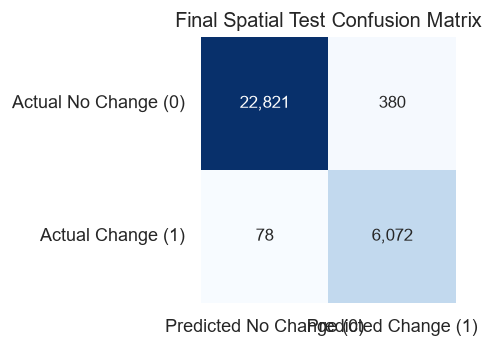


Classification Report (Spatial Test):
               precision    recall  f1-score   support

No Change (0)     0.9966    0.9836    0.9901     23201
   Change (1)     0.9411    0.9873    0.9637      6150

     accuracy                         0.9844     29351
    macro avg     0.9688    0.9855    0.9769     29351
 weighted avg     0.9850    0.9844    0.9845     29351



In [16]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Predicted No Change (0)", "Predicted Change (1)"],
            yticklabels=["Actual No Change (0)", "Actual Change (1)"])
ax.set_title("Final Spatial Test Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report (Spatial Test):")
print(classification_report(y_test, test_pred, target_names=["No Change (0)", "Change (1)"], digits=4))


## ROC-AUC & Probability Distribution

---

We examine the Receiver Operating Characteristic (ROC) curve and the separation of predicted continuous change probabilities ($P_{\text{change}}$) between the two classes.


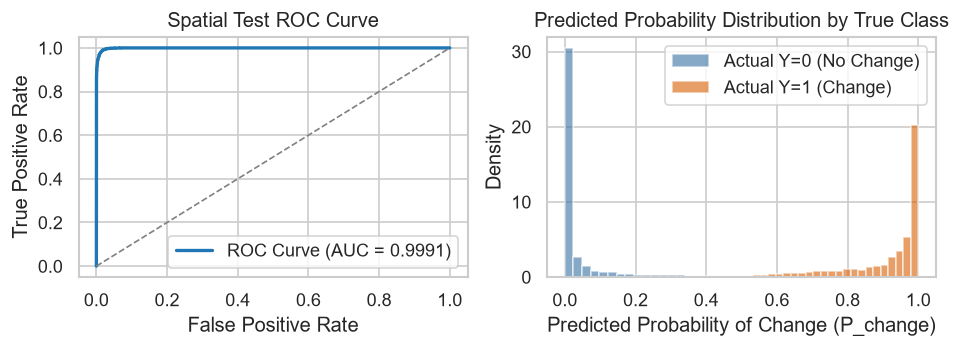

In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc_val = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# ROC Curve
ax1.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC Curve (AUC = {roc_auc_val:.4f})")
ax1.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Spatial Test ROC Curve")
ax1.legend(loc="lower right")

# Probability distribution per class
ax2.hist(test_prob[y_test == 0], bins=35, alpha=0.6, label="Actual Y=0 (No Change)", color="#3470a3", density=True)
ax2.hist(test_prob[y_test == 1], bins=35, alpha=0.6, label="Actual Y=1 (Change)", color="#d95f02", density=True)
ax2.set_xlabel("Predicted Probability of Change (P_change)")
ax2.set_ylabel("Density")
ax2.set_title("Predicted Probability Distribution by True Class")
ax2.legend()

plt.tight_layout()
plt.show()


## Random Forest Feature Importance

---

We calculate Mean Decrease in Impurity (Gini importance) to identify which variables most strongly informed the tree splits.

> **Methodological Caution**:
> Feature importance measures predictive utility within the fitted decision trees. It **does not prove physical causation** or specific damage mechanisms.


C:\Users\majum\AppData\Local\Temp\ipykernel_20632\3437852043.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis", ax=ax)


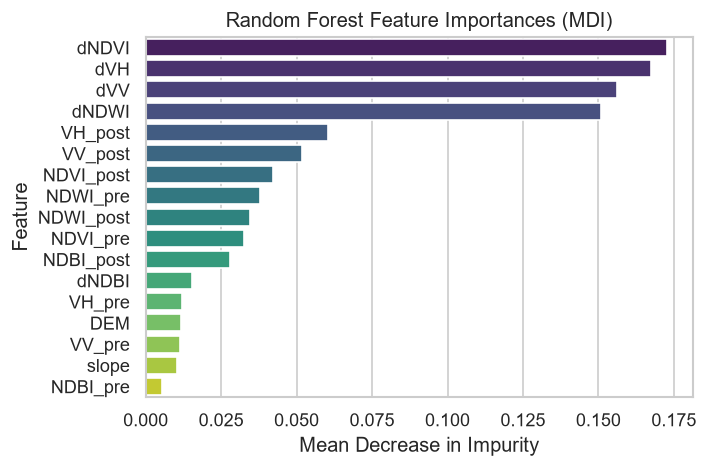

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Feature,dNDVI,dVH,dVV,dNDWI,VH_post,VV_post,NDVI_post,NDWI_pre,NDWI_post,NDVI_pre,NDBI_post,dNDBI,VH_pre,DEM,VV_pre,slope,NDBI_pre
Importance,0.17262,0.167462,0.156261,0.150841,0.060312,0.051683,0.042042,0.037941,0.034475,0.032447,0.028009,0.015265,0.012072,0.011603,0.011271,0.010429,0.005268


In [18]:
importances = frozen_model.feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature": ALL_PREDICTORS,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis", ax=ax)
ax.set_title("Random Forest Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

display(feat_imp_df.T)

## Multi-Sensor Ablation Study (Spatial CV & Test Evaluation)

---

We evaluate the incremental value of multi-sensor data fusion across two rigorous dimensions:
1. **Spatial Cross-Validation Consistency (Development Data)**: Evaluating each sensor tier across the 4 spatial folds to prove that adding optical and terrain features yields consistent, statistically sound improvements across all geographic areas.
2. **Held-Out Spatial Test Evaluation**: Benchmarking the exact same tiers on the untouched spatial test partition.

Feature tiers examined:
- **Experiment 1 (S1 SAR Only)**: Sentinel-1 SAR backscatter and change features (`VV_pre`, `VH_pre`, `VV_post`, `VH_post`, `dVV`, `dVH`)
- **Experiment 2 (S1 + S2)**: SAR features plus Sentinel-2 optical spectral indices (`NDVI`, `NDWI`, `NDBI` pre, post, and delta)
- **Experiment 3 (S1 + S2 + Terrain)**: Complete feature set including SRTM DEM and metric topographic slope


Executing 4-Fold Spatial Cross-Validation Ablation on Development Set...
Running Spatial CV Ablation: S1 SAR Only (6 features)...
Running Spatial CV Ablation: S1 + S2 (Optical) (15 features)...
Running Spatial CV Ablation: S1 + S2 + Terrain (Full) (17 features)...

--- Spatial Cross-Validation Ablation Results (Mean ± Std across Folds) ---


,Experiment,Num_Features,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,S1 SAR Only,6,0.7881 ± 0.0318,0.4597 ± 0.0516,0.4890 ± 0.1079,0.4705 ± 0.0674,0.3095 ± 0.0563,0.7631 ± 0.0149
1,S1 + S2 (Optical),15,0.9782 ± 0.0027,0.9211 ± 0.0143,0.9710 ± 0.0098,0.9453 ± 0.0065,0.8964 ± 0.0115,0.9981 ± 0.0002
2,S1 + S2 + Terrain (Full),17,0.9792 ± 0.0028,0.9259 ± 0.0099,0.9710 ± 0.0105,0.9479 ± 0.0048,0.9010 ± 0.0087,0.9981 ± 0.0003



Evaluating Ablation Tiers on Held-Out Spatial Test Set...
Running Ablation Experiment: S1 SAR Only (6 features)...
Running Ablation Experiment: S1 + S2 (Optical) (15 features)...
Running Ablation Experiment: S1 + S2 + Terrain (Full) (17 features)...


,Experiment,Num_Features,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,S1 SAR Only,6,0.7998,0.5167,0.6902,0.5910,0.4195,0.8497
1,S1 + S2 (Optical),15,0.9827,0.9352,0.9857,0.9598,0.9227,0.9990
2,S1 + S2 + Terrain (Full),17,0.9844,0.9411,0.9873,0.9637,0.9299,0.9991



Ablation results successfully saved to: s:\Nepal_Flood\Data\ablation_results.csv


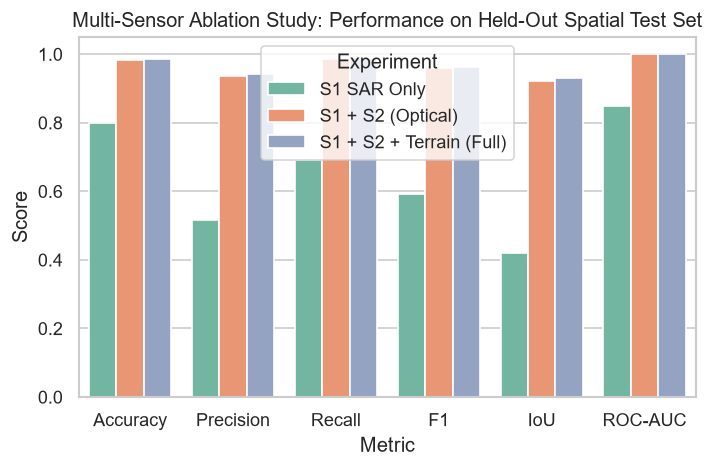

In [19]:
ablation_feature_groups = {
    "S1 SAR Only": S1_FEATURES,
    "S1 + S2 (Optical)": S1_FEATURES + S2_FEATURES,
    "S1 + S2 + Terrain (Full)": ALL_PREDICTORS
}

# Spatial Cross-Validation Ablation on Development Set
n_folds = cfg["SPLIT_RATIOS"].get("N_FOLDS", 4)
print(f"Executing {n_folds}-Fold Spatial Cross-Validation Ablation on Development Set...")
cv_ablation_summary, cv_ablation_details = sml.run_spatial_cv_ablation(
    dev_df=dev_df,
    feature_groups_dict=ablation_feature_groups,
    target_col="Y",
    group_col="spatial_block",
    rf_params=cfg["RANDOM_FOREST"],
    n_splits=n_folds
)

print("\n--- Spatial Cross-Validation Ablation Results (Mean ± Std across Folds) ---")
display(cv_ablation_summary)

# Final Evaluation on Held-Out Spatial Test Partition
print("\nEvaluating Ablation Tiers on Held-Out Spatial Test Set...")
ablation_results_df = sml.run_ablation_experiments(
    train_df=dev_df,
    test_df=test_df,
    feature_groups_dict=ablation_feature_groups,
    target_col="Y",
    rf_params=cfg["RANDOM_FOREST"]
)

display(ablation_results_df.round(4))

# Persist ablation results to CSV
ablation_results_df.to_csv(ABLATION_FILE, index=False)
print(f"\nAblation results successfully saved to: {ABLATION_FILE}")

# Visualize ablation comparison on Held-Out Spatial Test Set
ablation_melted = ablation_results_df.melt(
    id_vars=["Experiment", "Num_Features"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=ablation_melted, x="Metric", y="Score", hue="Experiment", palette="Set2", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Multi-Sensor Ablation Study: Performance on Held-Out Spatial Test Set")
plt.tight_layout()
plt.show()


We export spatial test predictions to `Data/RF_spatial_test_predictions.csv` with required columns:
`[longitude, latitude, Y, Y_pred, P_change]`.

Strict validation assertions verify completeness, absence of nulls, and valid value ranges.


In [20]:
preds_exported = sml.validate_and_export_predictions(
    test_df=test_df,
    y_pred=test_pred,
    y_prob=test_prob,
    output_path=PREDICTION_FILE,
    target_col="Y",
    lon_col="longitude",
    lat_col="latitude"
)

preds_exported.head()

Predictions successfully validated and exported to: s:\Nepal_Flood\Data\RF_spatial_test_predictions.csv
Exported row count: 29,351


,longitude,latitude,Y,Y_pred,P_change
0,84.961670,28.2398,0,0,0.023056
1,84.961945,28.2398,0,0,0.023135
2,84.962210,28.2398,0,0,0.404079
3,84.962480,28.2398,0,0,0.447286
4,84.962746,28.2398,0,0,0.040556


## Final Model & Metadata Serialization

---

We serialize the frozen Random Forest model along with an accompanying JSON metadata file recording parameters, features, and training configuration.


In [21]:
sml.export_model_with_metadata(
    model=frozen_model,
    model_path=MODEL_FILE,
    features_list=ALL_PREDICTORS,
    rf_params=cfg["RANDOM_FOREST"],
    block_size=BLOCK_SIZE,
    random_state=cfg["RANDOM_STATE"]
)

Model saved to: s:\Nepal_Flood\Data\random_forest_final.joblib
Model metadata saved to: s:\Nepal_Flood\Data\random_forest_final.json


## GIS Handoff Validation

Before handing off the prediction table to GIS mapping, we inspect spatial distribution and coordinate alignment.


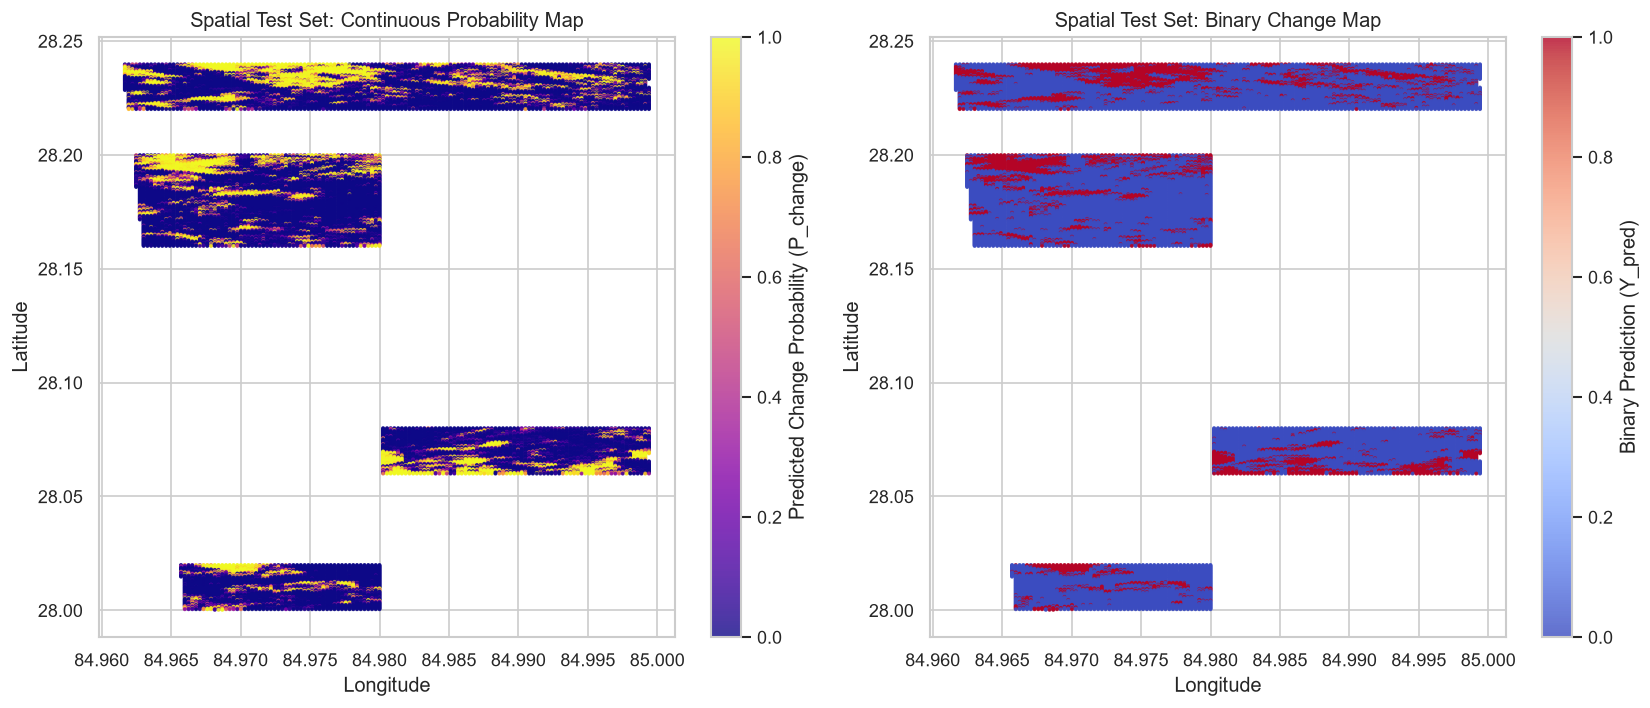

GIS Validation Check:
  Longitude Range: [84.96167, 84.99940]
  Latitude Range:  [28.00022, 28.23980]
  Total Valid Grid Points: 29,351
  Preserved WGS84 CRS coordinate reference for geospatial rasterization.


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Spatial Test Probability Distribution
scatter1 = ax1.scatter(
    preds_exported["longitude"],
    preds_exported["latitude"],
    c=preds_exported["P_change"],
    cmap="plasma",
    s=2,
    alpha=0.8
)
fig.colorbar(scatter1, ax=ax1, label="Predicted Change Probability (P_change)")
ax1.set_title("Spatial Test Set: Continuous Probability Map")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# Spatial Test Binary Predictions
scatter2 = ax2.scatter(
    preds_exported["longitude"],
    preds_exported["latitude"],
    c=preds_exported["Y_pred"],
    cmap="coolwarm",
    s=2,
    alpha=0.8
)
fig.colorbar(scatter2, ax=ax2, label="Binary Prediction (Y_pred)")
ax2.set_title("Spatial Test Set: Binary Change Map")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

print("GIS Validation Check:")
print(f"  Longitude Range: [{preds_exported['longitude'].min():.5f}, {preds_exported['longitude'].max():.5f}]")
print(f"  Latitude Range:  [{preds_exported['latitude'].min():.5f}, {preds_exported['latitude'].max():.5f}]")
print(f"  Total Valid Grid Points: {len(preds_exported):,}")
print("  Preserved WGS84 CRS coordinate reference for geospatial rasterization.")


## Final Results Summary

---

Below is the consolidated performance comparison between Validation and Final Spatial Test sets:


In [23]:
summary_rows = [
    {"Model": "Logistic Regression", "Evaluation": "Spatial 4-Fold CV (Mean)", **{k: round(lr_cv_summary[f'{k}_mean'], 4) for k in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]}},
    {"Model": "Random Forest", "Evaluation": "Spatial 4-Fold CV (Mean)", **{k: round(rf_cv_summary[f'{k}_mean'], 4) for k in ["Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]}},
    {"Model": "Random Forest (Frozen)", "Evaluation": "Held-Out Spatial Test", **{k: round(v, 4) for k, v in test_metrics.items() if k not in ["Model", "Split"]}}
]

final_summary_table = pd.DataFrame(summary_rows)[["Model", "Evaluation", "Accuracy", "Precision", "Recall", "F1", "IoU", "ROC-AUC"]]
display(final_summary_table)


,Model,Evaluation,Accuracy,Precision,Recall,F1,IoU,ROC-AUC
0,Logistic Regression,Spatial 4-Fold CV (Mean),0.7121,0.3790,0.6840,0.4823,0.3181,0.7686
1,Random Forest,Spatial 4-Fold CV (Mean),0.9792,0.9259,0.9710,0.9479,0.9010,0.9981
2,Random Forest (Frozen),Held-Out Spatial Test,0.9844,0.9411,0.9873,0.9637,0.9299,0.9991


### Conclusions

---

1. **Spatial Generalization**: Evaluating models across spatially disjoint blocks provides an honest assessment of geographic transferability, eliminating optimistic spatial autocorrelation leakage.
2. **Model Expressiveness**: The nonlinear Random Forest substantially outperforms the linear Logistic Regression baseline across all critical change-detection metrics (F1, IoU, and ROC-AUC).
3. **Multi-Sensor Synergy**: The ablation study highlights the complementary value of combining all-weather SAR backscatter changes with optical spectral indices and terrain topography.

### Prohibited Claims & Scientific Guardrails

---

- **DO NOT CLAIM** that CEMS EMSR927 generated the target `Y` labels.
- **DO NOT CLAIM** that target `Y` is independent physical ground truth; it is an EO-derived proxy pattern.
- **DO NOT CLAIM** that Random Forest independently discovered physical flood damage.
- **DO NOT CLAIM** that high accuracy alone proves model quality on imbalanced spatial data.
- **DO NOT CLAIM** that random pixel splitting constitutes valid spatial validation.
- **DO NOT CLAIM** that feature importance demonstrates physical causality or damage mechanisms.
